## VGG-19 Implementation

---

##### Architecture Diagram

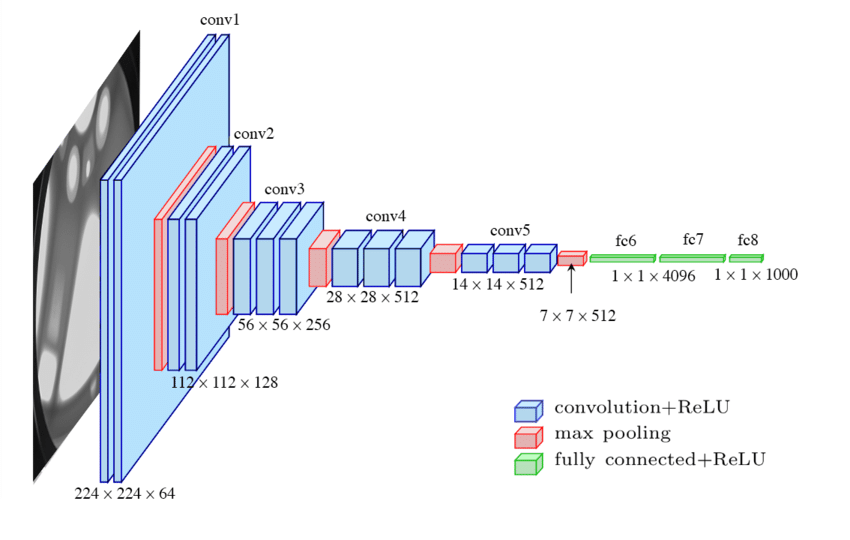

---

### Plan

Since I want the architecture implementation to be modular and easily swappable, I also want to keep the code structure consistent with the original VGG-19 design.
As shown in the architecture diagram and configuration table, VGG-19 is built by stacking convolution layers followed by a max-pooling layer. The first two stages contain 2 convolution layers + max pooling, while the later stages contain 4 convolution layers + max pooling.
To avoid repeating the same code and to keep the implementation clean, I plan to create a reusable block that accepts the number of convolution layers as a parameter and automatically builds:
Conv2D → ReLU → Conv2D → ReLU → ... → MaxPool
This way, each VGG stage can be created by simply specifying how many convolution layers it should contain

---

#### Configurations

In [1]:
config = {
    # ------------------------------- ConvNets Configurations -------------------------------
    "conv_kernel_size": 3,
    "conv_stride": 1,
    "padding": 1,
    "max_pool_stride": 2,
    "max_pool_kernel_size": 2,
    "hidden_channel_layer_1": 64,
    # ------------------------------- Fully Connected Layer Configurations -------------------------------
    "fc_in_features": 25088, # Output tensor of 16 ConvNets  = [B, 512, 7, 7] | flattening = 512 * 7 * 7 = 25088
    "fc_hidden_dim": 4096, 
    "n_classes": 200,

    # ------------------------------- VGG-19 Model Specific Configurations -------------------------------
    "in_channels": 3,
    "optimizer": "Adamw", # I will not use SGD (the one used in Original VGG-19 Paper)
    "weight_decay": 1e-4,
    "lr": 3e-4,
    "momentum": 0.9,
    "batch_size": 16,

    # ------------------------------ Image Configurations
    "img_size": 224,
}

---

### VGGBlock

In [2]:
import torch
import torch.nn as nn

In [ ]:
class VGGBlock(nn.Module):
    """
    Implements a reusable VGG building block.

    I wanted the VGG implementation to be modular so that different
    VGG variants can be created without repeating code. After studying
    the original architecture, I noticed that each stage follows the
    same pattern:

        Conv2D -> ReLU -> ... -> MaxPool

    The only thing that changes between stages is the number of
    convolution layers. This block abstracts that pattern and allows
    a stage to be created by simply specifying the number of
    convolution layers required.

    This keeps the implementation cleaner, easier to maintain,
    and closer to the design of the original paper.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                hidden_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                debug: bool = False):
                
                super(VGGBlock, self).__init__()

                self.debug = debug

                self.conv_1 = nn.Conv2d(
                    in_channels = in_channels,
                    out_channels = hidden_channels,
                    kernel_size = conv_kernel_size,
                    stride = conv_stride,
                    padding = padding
                )
                self.batch_norm_1 = nn.BatchNorm2d(hidden_channels)
                self.batch_norm_2 = nn.BatchNorm2d(hidden_channels)

                self.relu = nn.ReLU()

                self.conv_2 = nn.Conv2d(
                    in_channels = hidden_channels,
                    out_channels = hidden_channels,
                    kernel_size = conv_kernel_size,
                    stride = conv_stride,
                    padding = padding
                )

                # self.block = nn.Sequential(
                #     self.conv_1, self.relu, self.conv_2, self.relu
                # )
                self.block = nn.Sequential(
                    self.conv_1, self.batch_norm_1, self.relu, self.conv_2, self.batch_norm_2, self.relu
                )
    
    def forward(self, x: torch.Tensor):
        if self.debug:
            for i, layer in enumerate(self.block):
                x = layer(x)
                print(f"Layer {i:02d} ({layer.__class__.__name__}): {x.shape}")
            return x

        return self.block(x)
            

---

#### MaxPool Class

In [4]:
class MaxPool2d(nn.Module):
    """
    This class implements the max-pooling operation used throughout the
    VGG-19 architecture.

    Max pooling reduces the spatial resolution of feature maps while
    preserving the most dominant activations within each local region.
    This operation increases the receptive field of subsequent layers
    and improves computational efficiency by progressively downsampling
    the feature representations.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
            max_pool_stride: int = config["max_pool_stride"],
            max_pool_kernel_size: int = config["max_pool_kernel_size"]):
        
        super(MaxPool2d, self).__init__()
        
        self.max_pool_stride = max_pool_stride
        self.max_pool_kernel_size = max_pool_kernel_size

        self.max_pool2d = nn.MaxPool2d(
            kernel_size = self.max_pool_kernel_size,
            stride = self.max_pool_stride
        )
    
    def forward(self, x: torch.Tensor):
        return self.max_pool2d(x)

### ConvNets: Stacking VGGBocks

In [5]:
class ConvNets(nn.Module):
    """
    This class implements the convolutional feature extraction backbone of
    the VGG-19 architecture.

    The backbone is composed of stacked VGG blocks and max-pooling layers
    that progressively transform the input image into high-level feature
    representations. Spatial resolution is reduced through pooling while
    the number of feature channels is increased, enabling hierarchical
    feature learning across multiple scales.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                max_pool_stride: int = config["max_pool_stride"],
                max_pool_kernel_size: int = config["max_pool_kernel_size"],
                debug: bool = False):
        super(ConvNets, self).__init__()
        self.in_channels = in_channels
        prev_channels = config["hidden_channel_layer_1"]

        # Inserting 1st Layer (3 channel -> 64 channels) + MaxPool [2 ConvNets + ReLU]
        self.vgg_19_blocks = [
            nn.Sequential(VGGBlock(
                    in_channels = self.in_channels,
                    hidden_channels = config["hidden_channel_layer_1"],
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
            ), MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        ]
 
        # Inserting 2nd Layer (64 channel -> 128 channels) + MaxPool [2 ConvNets + ReLU]
        self.vgg_19_blocks.append(
            nn.Sequential(VGGBlock(
                in_channels = prev_channels,
                hidden_channels = 2 * prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),
            MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        )
        prev_channels *= 2

        # Inserting remaining 8 ConvNets + 2 MaxPools
        for _ in range(2):
            self.vgg_19_blocks.append(
                nn.Sequential(
                # 2 set of ConvNets with ReLU
                VGGBlock(
                    in_channels = prev_channels,
                    hidden_channels = 2 * prev_channels,
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
                ),
                # Again 2 set of ConvNets with ReLU
                VGGBlock(
                    in_channels = 2 * prev_channels,
                    hidden_channels = 2 * prev_channels,
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
                ),
                # MaxPool at the end of 4 consecutive ConvNets
                MaxPool2d(
                    max_pool_stride = max_pool_stride,
                    max_pool_kernel_size = max_pool_kernel_size
                ))
            )
            prev_channels *= 2

        # Insterting Last set of 4 ConvNets + 1 MaxPool
        self.vgg_19_blocks.append(
            nn.Sequential(
            # 2 set of ConvNets with ReLU
            VGGBlock(
                in_channels = prev_channels,
                hidden_channels = prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),
            # Again 2 set of ConvNets with ReLU
            VGGBlock(
                in_channels = prev_channels,
                hidden_channels = prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),

            # MaxPool at the end of 4 consecutive ConvNets
            MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        )
        self.vgg_19_layers = nn.Sequential(*self.vgg_19_blocks)
    
    def forward(self, x: torch.Tensor):
        return self.vgg_19_layers(x)

#### FullyConnected Layers

In [6]:
class FullyConnectedLayer(nn.Module):
    """
    This class implements the fully connected classification head of the
    VGG-19 architecture.

    The classifier consists of three linear layers with ReLU activations
    that transform high-level convolutional features into class scores.
    Prior to entering this module, spatial feature maps are flattened into
    a one-dimensional feature vector, enabling image-level classification.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_features: int,
                hidden_dim: int,
                out_features: int):
        super().__init__()
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.out_features = out_features

        self.linear_layer_1 = nn.Linear(in_features = self.in_features, out_features = self.hidden_dim)
        self.linear_layer_2 = nn.Linear(in_features = self.hidden_dim, out_features = self.hidden_dim)
        self.linear_layer_3 = nn.Linear(in_features = self.hidden_dim, out_features = self.out_features)
        self.relu = nn.ReLU()

        self.fc_layers = nn.Sequential(
            self.linear_layer_1, self.relu, self.linear_layer_2, self.relu, self.linear_layer_3
        )
    
    def forward(self, x: torch.Tensor):
        return self.fc_layers(x)

In [7]:
class VGG19(nn.Module):
    """
    This class implements the VGG-19 architecture proposed in the paper
    "Very Deep Convolutional Networks for Large-Scale Image Recognition".

    The model consists of a convolutional feature extractor built from
    stacked 3×3 convolution layers and max-pooling operations, followed
    by a fully connected classifier. The implementation is organized into
    separate feature extraction and classification modules to promote
    modularity, reproducibility, and ease of experimentation.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                max_pool_stride: int = config["max_pool_stride"],
                max_pool_kernel_size: int = config["max_pool_kernel_size"],
                in_features: int = config["fc_in_features"],
                hidden_dim: int = config["fc_hidden_dim"],
                out_features: int = config["n_classes"],
                debug: bool = False):
        super().__init__()


        self.features = ConvNets(
            in_channels = in_channels,
            conv_kernel_size = conv_kernel_size,
            conv_stride = conv_stride,
            padding = padding,
            max_pool_stride = max_pool_stride,
            max_pool_kernel_size = max_pool_kernel_size,
            debug = debug
        )

        self.flatten = nn.Flatten(start_dim=1)

        self.classifier = FullyConnectedLayer(
            in_features = in_features,
            hidden_dim = hidden_dim,
            out_features = out_features
        )
        # Proper weight initialization, used by the Original Paper, they explicitly mentioned this:
            # The weights were initialized by sampling from a normal distribution with mean 0 and standard deviation 0.01.
            # The biases were initialized with zero.
        # self.initialize_weights()
        self.init_weights()
    
    def forward(self, x):
        x = self.features(x)
        assert x.shape[1:] == (512, 7, 7), f"Expected (512, 7, 7), got {x.shape}"
        x = self.flatten(x)
        x = self.classifier(x)
        return x
    
    # def initialize_weights(self):
    #     for m in self.modules():
    #         if isinstance(m, nn.Conv2d):
    #             nn.init.normal_(
    #                 m.weight,
    #                 mean=0.0,
    #                 std=0.01
    #             )

    #             if m.bias is not None:
    #                 nn.init.constant_(m.bias, 0)

    #         elif isinstance(m, nn.Linear):
    #             nn.init.normal_(
    #                 m.weight,
    #                 mean=0.0,
    #                 std=0.01
    #             )

    #             nn.init.constant_(
    #                 m.bias,
    #                 0
    #             )
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(
                    m.weight,
                    nonlinearity="relu"
                )
                nn.init.zeros_(m.bias)

#### Tensor Shape Verification

In [8]:
vgg_19 = VGG19(
    in_channels = 3,
    debug = True
)

x = torch.rand(64, 3, 224, 224)
print(f"Input Tensor Shape = {x.shape}")
print("-" * 60)
y = vgg_19(x)
print("-" * 60)
print(f"Output Tensor Shape = {y.shape}")

Input Tensor Shape = torch.Size([64, 3, 224, 224])
------------------------------------------------------------
Layer 00 (Conv2d): torch.Size([64, 64, 224, 224])
Layer 01 (ReLU): torch.Size([64, 64, 224, 224])
Layer 02 (Conv2d): torch.Size([64, 64, 224, 224])
Layer 03 (ReLU): torch.Size([64, 64, 224, 224])
Layer 00 (Conv2d): torch.Size([64, 128, 112, 112])
Layer 01 (ReLU): torch.Size([64, 128, 112, 112])
Layer 02 (Conv2d): torch.Size([64, 128, 112, 112])
Layer 03 (ReLU): torch.Size([64, 128, 112, 112])
Layer 00 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 01 (ReLU): torch.Size([64, 256, 56, 56])
Layer 02 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 03 (ReLU): torch.Size([64, 256, 56, 56])
Layer 00 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 01 (ReLU): torch.Size([64, 256, 56, 56])
Layer 02 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 03 (ReLU): torch.Size([64, 256, 56, 56])
Layer 00 (Conv2d): torch.Size([64, 512, 28, 28])
Layer 01 (ReLU): torch.Size([64, 512, 28, 28])
Layer 02 (Co

In [9]:
def get_params(model):
    feature_params = sum(p.numel() for p in model.features.parameters())
    classifier_params = sum(p.numel() for p in model.classifier.parameters())
    total_params = feature_params + classifier_params
    return feature_params, classifier_params, total_params

feature_params, classifier_params, total_params = get_params(model = vgg_19)


print("=" * 60)
print("Model Parameter Statistics")
print("=" * 60)
print(f"Feature Parameters: {feature_params:,} ({feature_params/1e6:.2f} M)")
print(f"Classifier Parameters: {classifier_params:,} ({classifier_params/1e6:.2f} M)")
print(f"Total Parameters: {total_params:,} ({total_params/1e6:.2f} M)")
print("-" * 60)
print(f"Total Parameters: {total_params:,} ({total_params/1e6:.2f} M)")
print("=" * 60)

Model Parameter Statistics
Feature Parameters: 20,024,384 (20.02 M)
Classifier Parameters: 120,365,256 (120.37 M)
Total Parameters: 140,389,640 (140.39 M)
------------------------------------------------------------
Total Parameters: 140,389,640 (140.39 M)


### Saving and Loading Scripts

In [10]:
import torch

def save_checkpoint(
    model,
    optimizer,
    epoch: int,
    loss: float,
    filepath: str
):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "loss": loss,
        "config": config
    }

    torch.save(checkpoint, filepath)

In [11]:
def load_checkpoint(
    filepath: str,
    model,
    optimizer=None,
    device="cpu"
):
    checkpoint = torch.load(
        filepath,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    epoch = checkpoint.get("epoch", 0)
    loss = checkpoint.get("loss", None)
    config = checkpoint.get("config")

    return model, optimizer, epoch, loss, config

In [12]:
# Saving the model script
"""
save_checkpoint(
    model,
    optimizer,
    epoch,
    loss,
    "latest_checkpoint.pth"
)
"""

# Loading the Model for Training
"""
model, optimizer, epoch, loss, config = load_checkpoint(
    filepath="checkpoints/latest_checkpoint.pth",
    model=model,
    optimizer=optimizer,
    device=device
)

start_epoch = epoch + 1
"""

# Loading the Model for Inference
"""
model, _, _, _, config = load_checkpoint(
    "best_model.pth",
    model,
    optimizer=None,
    device=device
)

model.eval()

with torch.no_grad():
    logits = model(image)
    pred = torch.argmax(logits, dim=-1)
"""


'\nmodel, _, _, _, config = load_checkpoint(\n    "best_model.pth",\n    model,\n    optimizer=None,\n    device=device\n)\n\nmodel.eval()\n\nwith torch.no_grad():\n    logits = model(image)\n    pred = torch.argmax(logits, dim=-1)\n'

---

##### Reorganize Validation dir for Classification task

In [13]:
## Run this Once


# import os
# import shutil

# val_dir = "../data/tiny-imagenet-200/val"
# img_dir = os.path.join(val_dir, "images")
# annotation_file = os.path.join(val_dir, "val_annotations.txt")

# with open(annotation_file, "r") as f:
#     for line in f.readlines():
#         image_name, class_name, *_ = line.split("\t")

#         class_dir = os.path.join(val_dir, class_name)
#         os.makedirs(class_dir, exist_ok=True)

#         src = os.path.join(img_dir, image_name)
#         dst = os.path.join(class_dir, image_name)

#         if os.path.exists(src):
#             shutil.move(src, dst)

# shutil.rmtree(img_dir)

# print("Validation folder reorganized successfully.")

---

## Get the Dataset and Prepare DataLoader

##### Data Augmentation

- Random Horizontal Flip: Randomly flips images during training.
- Random Crop: Randomly crops images to help the model learn objects at slightly different positions.

##### Preprocessing

- Normalize image channels using:

  x_norm = (x - mean) / std

- Mean = [0.485, 0.456, 0.406]
- Std = [0.229, 0.224, 0.225]

These values were computed from millions of images in the ImageNet dataset and help stabilize training by keeping the input distribution consistent.

In [14]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

IMAGE_SIZE = config["img_size"]
BATCH_SIZE = config["batch_size"]
NUM_WORKERS = 0

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(
        IMAGE_SIZE,
        padding=4
    ),
    transforms.ToTensor(),

    # Normalize accross channel_dim; means = [red_mean, green_mean, blue_mean]; similary for std
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ) # There's numbers are analyzed accross Millions of Images and then they're computed 
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root="../data/tiny-imagenet-200/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root="../data/tiny-imagenet-200/val",
    transform=val_transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train Samples: {len(train_dataset):,}")
print(f"Validation Samples: {len(val_dataset):,}")
print(f"Classes: {len(train_dataset.classes)}")

Train Samples: 100,000
Validation Samples: 10,000
Classes: 200


In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


---

#### Experiment Tracking

In [16]:
import wandb

def initialize_wandb(device):
    wandb.init(
        project="vgg19-from-scratch",
        name="vgg19_tinyimagenet_adamw_original_init",
        tags=[
            "vgg19",
            "tiny-imagenet",
            "from-scratch",
            "paper-reproduction"
        ],

        config={
            # Dataset
            "dataset": "TinyImageNet",
            "num_classes": config["n_classes"],
            "image_size": config["img_size"],

            # Architecture
            "architecture": "VGG19",
            "conv_layers": 16,
            "maxpool_layers": 5,
            "fc_layers": 3,

            # Parameters
            "feature_params": feature_params,
            "classifier_params": classifier_params,
            "total_params": total_params,

            # Training
            "epochs": config["epochs"],
            "batch_size": config["batch_size"],

            # Optimizer
            "optimizer": config["optimizer"],
            "learning_rate": config["lr"],
            "momentum": config["momentum"],
            "weight_decay": config["weight_decay"],

            # Initialization
            "weight_init": "Normal(0, 0.01)",
            "bias_init": "Zero",

            # Loss
            "loss_fn": "CrossEntropyLoss",

            # Hardware
            "device": str(device)
        }
    )

---

#### Training Script

In [17]:
def train_model(model, optimizer, loader, device):
    wandb.watch(
        model,
        log="all",
        log_freq=100
    )
    initialize_wandb(device)
    model = model.to(device)

---

### Getting the Model ready for Training

In [18]:
model = VGG19(
    in_channels = config["in_channels"]
)
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=0.01,
#     weight_decay=1e-4
# )
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

In [19]:
def overfit(overfit_epoch: int, overfit_batch_size: int = 2):
    def get_accuracy(logits, target):
        y_preds = torch.argmax(logits, dim = -1)
        acc = (y_preds == target).sum() / target.shape[0]
        return acc
    
    model = VGG19(
        in_channels = config["in_channels"]
    )
    overfit_lr = 0.0001
    overfit_momemtum = 0.9
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr= overfit_lr,
        momentum = overfit_momemtum
    )
    # optimizer = torch.optim.AdamW(
    #     model.parameters(),
    #     lr=1e-3,
    #     weight_decay=0
    # )
    
    img_overfit = images[:overfit_batch_size]
    labels_overfit = labels[:overfit_batch_size]
    loss_fn = nn.CrossEntropyLoss()

    print(f"Overfitting the Model on Batch Size = {overfit_batch_size} | Epochs = {overfit_epoch}")
    preds = model(img_overfit).argmax(-1)
    print(f"Initial Predictions: {preds}")
    print(f"Original Labels: {labels_overfit}")
    model.train()
    for epoch in range(overfit_epoch):
        logits = model(img_overfit)
        loss = loss_fn(
            logits,
            labels_overfit
        )
        acc = get_accuracy(logits, labels_overfit)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 2 == 0:
            print(f"Epoch [{epoch}/{overfit_epoch}] | Loss = {loss:.3f} | Accuracy = {acc * 100}%")
            if acc.item() >= 0.999:
                print("\n-------------------------------------- Overfitting Sucessfull -------------------------------------- \n")
                print(f"Details:")
                print(f"> Exiting at Epochs: {epoch}")
                print(f"> lr = {overfit_lr}")
                print(" > Forward pass works")
                print(" > Backward pass works")
                print(" > Labels are correct")
                print(" > Optimizer works")
                print(" > Architecture is trainable")
                print(f"\nPredictions = {logits.argmax(-1)} | Original Labels: {labels_overfit}\n")
                break
    return model

overfitted_model = overfit(overfit_epoch = 100, overfit_batch_size = 10)

Overfitting the Model on Batch Size = 10 | Epochs = 100
Initial Predictions: tensor([149, 149,  72, 149, 149, 149, 149, 149, 149, 149])
Original Labels: tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31])
Epoch [0/100] | Loss = 5.315 | Accuracy = 0.0%
Epoch [2/100] | Loss = 5.293 | Accuracy = 0.0%
Epoch [4/100] | Loss = 5.250 | Accuracy = 0.0%
Epoch [6/100] | Loss = 5.194 | Accuracy = 0.0%
Epoch [8/100] | Loss = 5.129 | Accuracy = 10.0%
Epoch [10/100] | Loss = 5.058 | Accuracy = 10.0%
Epoch [12/100] | Loss = 4.979 | Accuracy = 10.0%
Epoch [14/100] | Loss = 4.889 | Accuracy = 20.0%
Epoch [16/100] | Loss = 4.786 | Accuracy = 20.0%
Epoch [18/100] | Loss = 4.663 | Accuracy = 20.0%
Epoch [20/100] | Loss = 4.515 | Accuracy = 20.0%
Epoch [22/100] | Loss = 4.328 | Accuracy = 20.0%
Epoch [24/100] | Loss = 4.084 | Accuracy = 20.0%
Epoch [26/100] | Loss = 3.758 | Accuracy = 20.0%
Epoch [28/100] | Loss = 3.324 | Accuracy = 10.0%
Epoch [30/100] | Loss = 2.798 | Accuracy = 10.0%
Epoch [32/100

In [ ]:
# Using BatchNorm + SGD (lr = 0.001, momentum = 0.9)

# Overfitting the Model on Batch Size = 10 | Epochs = 100

# Initial Predictions: tensor([ 50,  50,  27, 194,  26,  50,  18,  50,  50, 182])

# Original Labels: tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150])

# Epoch [0/100] | Loss = 6.528 | Accuracy = 0.0%

# Epoch [2/100] | Loss = 1.629 | Accuracy = 40.0%

# Epoch [4/100] | Loss = 0.652 | Accuracy = 70.0%

# Epoch [6/100] | Loss = 0.278 | Accuracy = 90.0%

# Epoch [8/100] | Loss = 0.073 | Accuracy = 100.0%



# -------------------------------------- Overfitting Sucessfull -------------------------------------- 



# Details:

# > Exiting at Epochs: 8

# > lr = 0.001

#  > Forward pass works

#  > Backward pass works

#  > Labels are correct

#  > Optimizer works

#  > Architecture is trainable



# Predictions = tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150]) | Original Labels: tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150])


# Not using BatchNorm + SGD (lr = 0.001; momentum = 0.9)
# Overfitting the Model on Batch Size = 10 | Epochs = 100
# Initial Predictions: tensor([109, 109, 109, 133, 109, 109, 109, 109, 109, 109])
# Original Labels: tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52])
# Epoch [0/100] | Loss = 5.321 | Accuracy = 0.0%
# Epoch [2/100] | Loss = 5.139 | Accuracy = 10.0%
# ..
# ..
# ..
# Epoch [82/100] | Loss = 0.813 | Accuracy = 90.0%
# Epoch [84/100] | Loss = 0.660 | Accuracy = 90.0%
# Epoch [86/100] | Loss = 0.490 | Accuracy = 90.0%
# Epoch [88/100] | Loss = 0.273 | Accuracy = 90.0%
# Epoch [90/100] | Loss = 0.029 | Accuracy = 100.0%

# -------------------------------------- Overfitting Sucessfull -------------------------------------- 

# Details:
# > Exiting at Epochs: 90
# > lr = 0.001
#  > Forward pass works
#  > Backward pass works
#  > Labels are correct
#  > Optimizer works
#  > Architecture is trainable

# Predictions = tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52]) | Original Labels: tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52])


# Not Using BatchNorm Optimizer = SGD (lr = 0.0001), momentum = 0.9
# Overfitting the Model on Batch Size = 10 | Epochs = 100
# Initial Predictions: tensor([149, 149,  72, 149, 149, 149, 149, 149, 149, 149])
# Original Labels: tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31])
# Epoch [0/100] | Loss = 5.315 | Accuracy = 0.0%
# Epoch [2/100] | Loss = 5.293 | Accuracy = 0.0%
# Epoch [4/100] | Loss = 5.250 | Accuracy = 0.0%
# Epoch [6/100] | Loss = 5.194 | Accuracy = 0.0%
# Epoch [8/100] | Loss = 5.129 | Accuracy = 10.0%
# Epoch [10/100] | Loss = 5.058 | Accuracy = 10.0%
# Epoch [12/100] | Loss = 4.979 | Accuracy = 10.0%
# Epoch [14/100] | Loss = 4.889 | Accuracy = 20.0%
# Epoch [16/100] | Loss = 4.786 | Accuracy = 20.0%
# Epoch [18/100] | Loss = 4.663 | Accuracy = 20.0%
# Epoch [20/100] | Loss = 4.515 | Accuracy = 20.0%
# Epoch [22/100] | Loss = 4.328 | Accuracy = 20.0%
# Epoch [24/100] | Loss = 4.084 | Accuracy = 20.0%
# Epoch [26/100] | Loss = 3.758 | Accuracy = 20.0%
# Epoch [28/100] | Loss = 3.324 | Accuracy = 10.0%
# Epoch [30/100] | Loss = 2.798 | Accuracy = 10.0%
# Epoch [32/100] | Loss = 2.280 | Accuracy = 10.0%
# Epoch [34/100] | Loss = 1.800 | Accuracy = 60.000003814697266%
# Epoch [36/100] | Loss = 1.412 | Accuracy = 90.0%
# Epoch [38/100] | Loss = 1.118 | Accuracy = 80.0%
# Epoch [40/100] | Loss = 0.722 | Accuracy = 100.0%

# -------------------------------------- Overfitting Sucessfull -------------------------------------- 

# Details:
# > Exiting at Epochs: 40
# > lr = 0.0001
#  > Forward pass works
#  > Backward pass works
#  > Labels are correct
#  > Optimizer works
#  > Architecture is trainable

# Predictions = tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31]) | Original Labels: tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31])



In [21]:
img = images[:2]
labels = labels[:2]
overfitted_model(img).argmax(-1)

tensor([ 88, 112])

#### Save the Trained Model

#### Load the Trained Model

#### Prediction from Loaded Model